In [ ]:
# --- Install dependencies ---
# !pip install -q kaggle pandas numpy matplotlib opencv-python torch torchvision tqdm scikit-learn

# downloading dataset failed 
# download dataset manually from kaggle and place in the dataset/ folder

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [4]:
# Dataset paths
dataset_path = "dataset/"
train_dataset_path = os.path.join(dataset_path, "train")
test_dataset_path = os.path.join(dataset_path, "test")

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        self.image_files = []
        self.mask_files = []
        
        if os.path.exists(image_dir) and os.path.exists(mask_dir):
            png_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
            
            for filename in png_files:
                img_path = os.path.join(image_dir, filename)
                mask_path = os.path.join(mask_dir, filename)  
                
                self.image_files.append(img_path)
                self.mask_files.append(mask_path)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_files[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_files[idx], cv2.IMREAD_GRAYSCALE)
        
        if self.transform:
            image = self.transform(image)
        else:
            image = cv2.resize(image, (224, 224))
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        
        mask = cv2.resize(mask, (224, 224))
        mask = torch.from_numpy(mask).long()

        mask = (mask > 127).long() 
        
        return image, mask


In [ ]:
# Device selection: cuda -> mps -> cpu
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

# Image preprocessing (single, shared definition)
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
train_images_path = os.path.join(train_dataset_path, 'Original')
train_masks_path = os.path.join(train_dataset_path, 'Ground truth')
test_images_path = os.path.join(test_dataset_path, 'Original')
test_masks_path = os.path.join(test_dataset_path, 'Ground truth')

full_train_ds = SegmentationDataset(train_images_path, train_masks_path, transform)
test_ds = SegmentationDataset(test_images_path, test_masks_path, transform)

train_size = int(0.8 * len(full_train_ds))
val_size = len(full_train_ds) - train_size

train_ds, val_ds = torch.utils.data.random_split(
    full_train_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# pin_memory only helps on CUDA; on MPS it gives nothing and can warn
num_workers = 2
pin_memory = (device.type == "cuda")

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False,
                        num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False,
                         num_workers=num_workers, pin_memory=pin_memory)

print(f"Training: {len(train_ds)}")
print(f"Validation: {len(val_ds)}")
print(f"Test: {len(test_ds)}")


Training dataset samples:


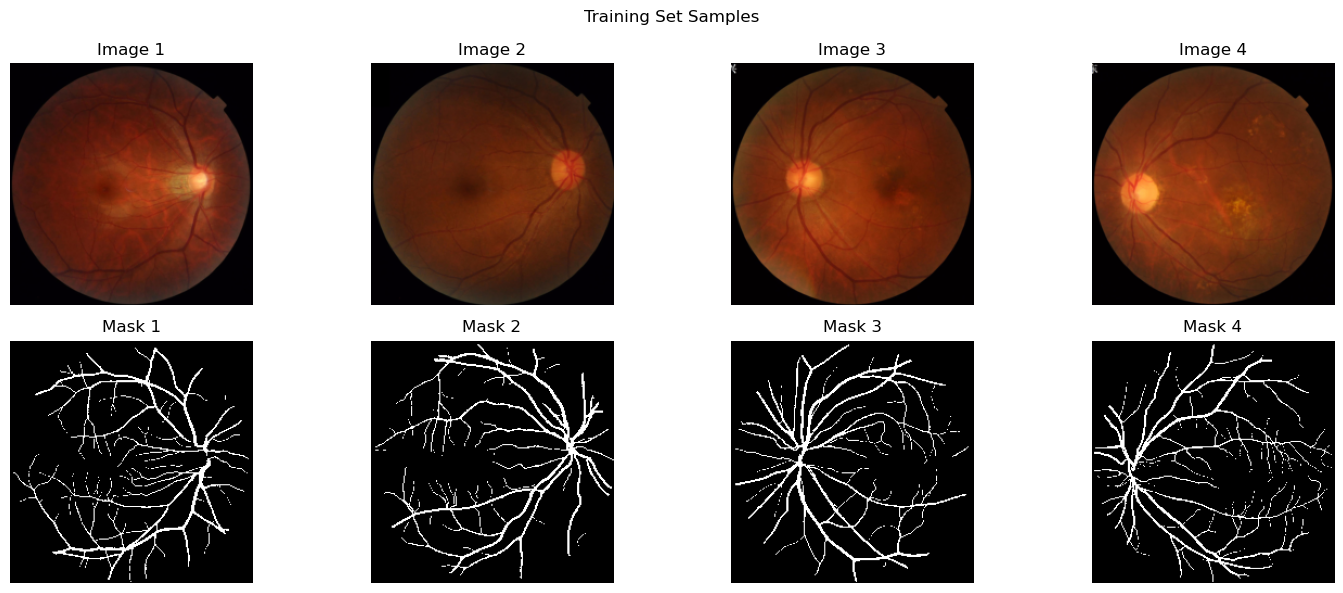


Validation dataset samples:


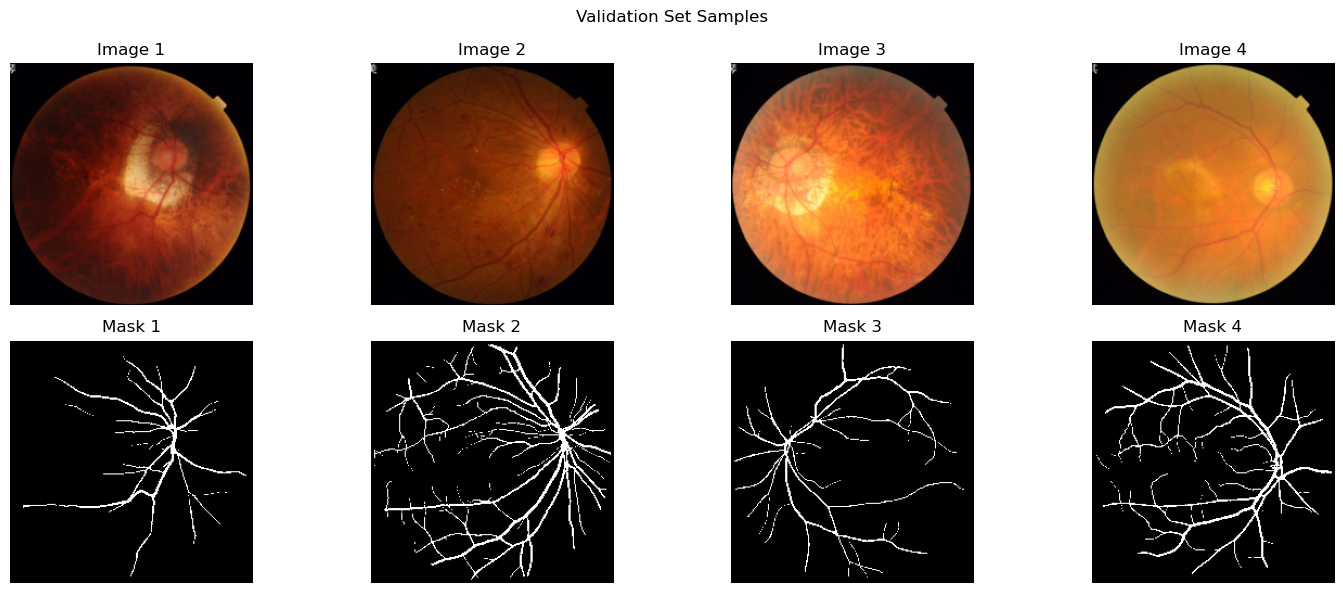

In [8]:
# Visualize dataset
def visualize_samples(dataset, num_samples=4, title="Dataset Samples"):
    
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    
    for i in range(min(num_samples, len(dataset))):
        img, mask = dataset[i]
        
        if isinstance(img, torch.Tensor):
            if img.shape[0] == 3:
                img_np = img.permute(1, 2, 0).numpy()
            else:
                img_np = img.squeeze().numpy()
        else:
            img_np = img
            
        if isinstance(mask, torch.Tensor):
            mask_np = mask.numpy()
        else:
            mask_np = mask
        
        if img_np.min() < 0:
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_np = img_np * std + mean
            img_np = np.clip(img_np, 0, 1)
        elif img_np.max() <= 1:
            pass  
        else:
            img_np = img_np / 255.0 
        
        axes[0, i].imshow(img_np)
        axes[0, i].set_title(f'Image {i+1}')
        axes[0, i].axis('off')
        
        axes[1, i].imshow(mask_np, cmap='gray')
        axes[1, i].set_title(f'Mask {i+1}')
        axes[1, i].axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

if 'train_ds' in locals() and len(train_ds) > 0:
    print("Training dataset samples:")
    visualize_samples(train_ds, 4, "Training Set Samples")
    
if 'val_ds' in locals() and len(val_ds) > 0:
    print("\nValidation dataset samples:")
    visualize_samples(val_ds, 4, "Validation Set Samples")


In [ ]:
class SegmentationModel(nn.Module):
    def __init__(self, num_classes=2):
        super(SegmentationModel, self).__init__()

        self.enc1 = self.conv_block(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        
        self.enc2 = self.conv_block(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        
        self.enc3 = self.conv_block(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        
        self.enc4 = self.conv_block(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        
        self.bottleneck = self.conv_block(512, 1024)
        
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = self.conv_block(1024, 512)  
        
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = self.conv_block(512, 256)
        
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self.conv_block(256, 128)
        
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = self.conv_block(128, 64)
        
        self.out = nn.Conv2d(64, num_classes, 1)
    
    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        enc1 = self.enc1(x)       
        enc2 = self.enc2(self.pool1(enc1)) 
        enc3 = self.enc3(self.pool2(enc2)) 
        enc4 = self.enc4(self.pool3(enc3)) 
        
        bottleneck = self.bottleneck(self.pool4(enc4)) 
        
        dec4 = self.upconv4(bottleneck)  
        dec4 = torch.cat([dec4, enc4], dim=1) 
        dec4 = self.dec4(dec4)
        
        dec3 = self.upconv3(dec4) 
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)
        
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)
        
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)
        
        out = self.out(dec1)
        return out

model = SegmentationModel(num_classes=2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 

num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")

In [ ]:
EPOCHS = 15  # set to a small number (e.g. 1-2) for a quick smoke test

# Cosine annealing LR schedule, stepped once per epoch
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss = float("inf")
best_model_path = "best_segmentation_model.pth"

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    train_samples = 0

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    for imgs, masks in tqdm(train_loader, desc="Training"):
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_samples += imgs.size(0)

    model.eval()
    val_loss = 0
    val_samples = 0
    correct_pixels = 0
    total_pixels = 0

    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc="Validation"):
            imgs, masks = imgs.to(device), masks.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_samples += imgs.size(0)

            predicted = torch.argmax(outputs, dim=1)
            correct_pixels += (predicted == masks).sum().item()
            total_pixels += masks.numel()

    # Step the LR scheduler once per epoch
    scheduler.step()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    pixel_accuracy = correct_pixels / total_pixels

    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Pixel Accuracy: {pixel_accuracy:.4f}")
    print(f"LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save the best model (lowest validation loss) as a pure state_dict
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved best model (val loss {best_val_loss:.4f}) -> {best_model_path}")

print("\nTraining completed!")


# Model Evaluation



In [13]:
model.eval()

test_loss = 0
correct_pixels = 0
total_pixels = 0
all_predictions = []
all_targets = []

print("Evaluating...")

with torch.no_grad():
    for imgs, masks in tqdm(test_loader):
        imgs, masks = imgs.to(device), masks.to(device)
        
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        test_loss += loss.item()
        
        predicted = torch.argmax(outputs, dim=1)
        
        correct_pixels += (predicted == masks).sum().item()
        total_pixels += masks.numel()
        
        all_predictions.extend(predicted.cpu().numpy().flatten())
        all_targets.extend(masks.cpu().numpy().flatten())

avg_test_loss = test_loss / len(test_loader)
pixel_accuracy = correct_pixels / total_pixels

print(f"\nTest Results:")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Pixel Accuracy: {pixel_accuracy:.4f}")

from sklearn.metrics import jaccard_score

iou = jaccard_score(all_targets, all_predictions, average='binary')
print(f"IoU Score: {iou:.4f}")

def calculate_dice_score(targets, predictions):
    targets = np.array(targets)
    predictions = np.array(predictions)
    
    intersection = np.sum(targets * predictions)
    dice = (2. * intersection) / (np.sum(targets) + np.sum(predictions) + 1e-8)
    
    return dice

dice_score = calculate_dice_score(all_targets, all_predictions)
print(f"Dice Score: {dice_score:.4f}")

Evaluating...


100%|██████████| 25/25 [00:42<00:00,  1.71s/it]




Test Results:
Test Loss: 0.0894
Pixel Accuracy: 0.9758
IoU Score: 0.7010
IoU Score: 0.7010
Dice Score: 0.8242
Dice Score: 0.8242
